# 05 · GSE65391 · RNA_array · WGCNA modules

Reads `wgcna_input.rds`. Writes `data/run_artifacts/GSE65391/modules.rds` and the end product
`data/run_artifacts/GSE65391/module_genes.csv`.

`blockwiseModules` settings, all stated:

| setting | value | why |
|---|---|---|
| networkType, TOMType | signed | a module holds genes that rise together, not genes that move in opposite directions |
| power | from notebook 04 | scale-free fit |
| minModuleSize | 30 | the WGCNA tutorial value for gene expression |
| mergeCutHeight | 0.25 | merge modules whose eigengenes correlate above 0.75 (tutorial value) |
| maxBlockSize | 10000 | all expressed genes in one block |

Genes that fit no module are labelled `grey`.

In [1]:
if (!requireNamespace("WGCNA", quietly = TRUE)) install.packages("WGCNA", repos = "https://cloud.r-project.org")
suppressMessages(library(WGCNA))
source("../src/paths.R")
w <- readRDS(art("GSE65391", "wgcna_input.rds"))
c(samples = nrow(w$datExpr), genes = ncol(w$datExpr), power = w$power)

samples   genes   power 
    157    8825      20

In [2]:
set.seed(SEED)
net <- blockwiseModules(w$datExpr, power = w$power, networkType = "signed", TOMType = "signed",
                        minModuleSize = 30, mergeCutHeight = 0.25, maxBlockSize = 10000,
                        numericLabels = FALSE, pamRespectsDendro = FALSE, verbose = 0)
sizes <- sort(table(net$colors), decreasing = TRUE)
c(modules = sum(names(sizes) != "grey"), genes_in_modules = sum(sizes[names(sizes) != "grey"]),
  grey = unname(sizes["grey"]))
sizes

modules genes_in_modules             grey 
              16             6381             2444


   turquoise         grey         blue        brown       yellow        green 
        3013         2444          942          426          416          301 
         red        black         pink      magenta       purple  greenyellow 
         268          250          247          103           94           84 
      salmon          tan         cyan midnightblue    lightcyan 
          55           55           47           44           36 

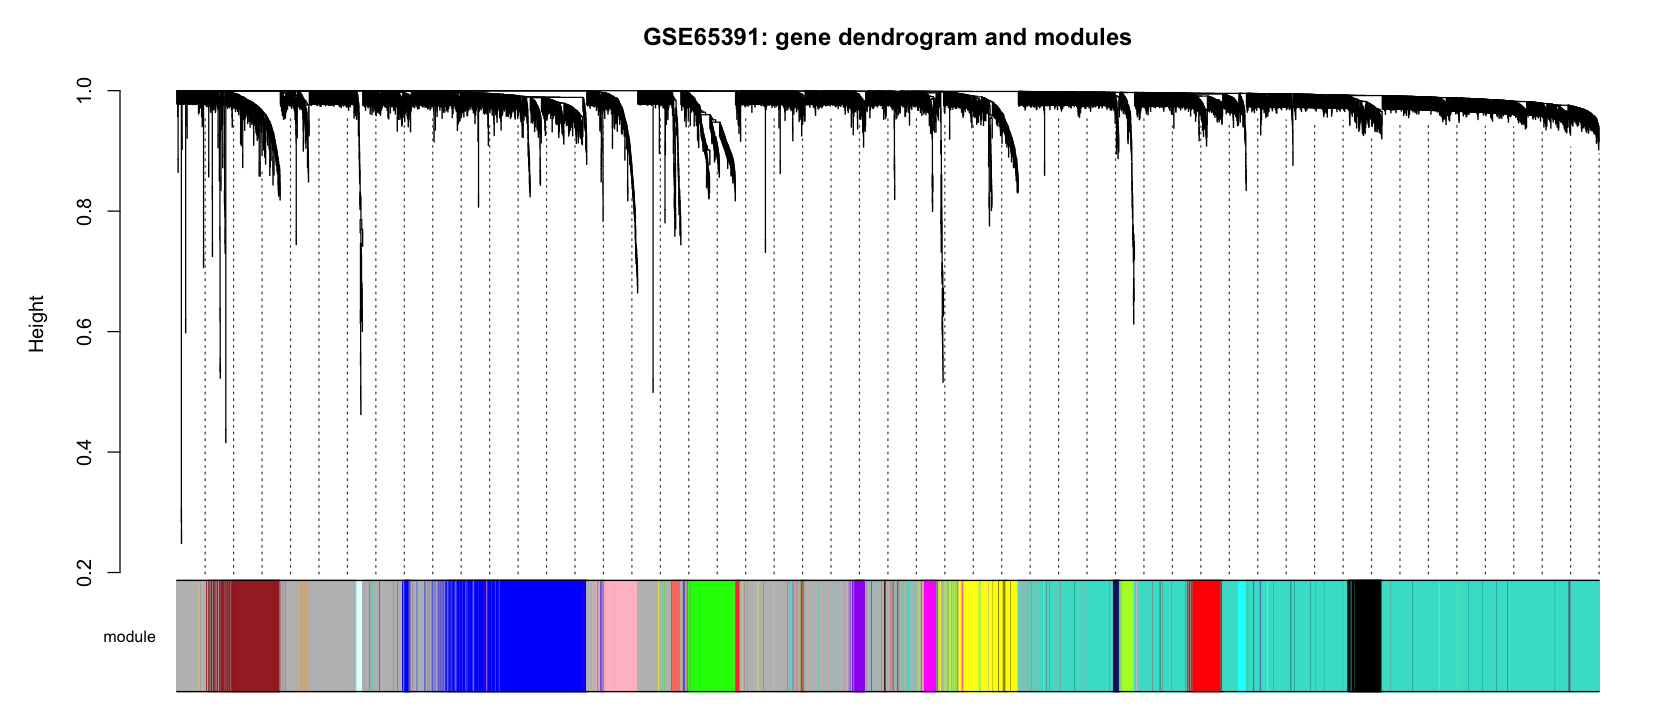

In [3]:
options(repr.plot.width = 14, repr.plot.height = 6)
plotDendroAndColors(net$dendrograms[[1]], net$colors[net$blockGenes[[1]]], "module",
                    dendroLabels = FALSE, hang = 0.03, addGuide = TRUE, guideHang = 0.05,
                    main = "GSE65391: gene dendrogram and modules")

**Module membership (kME).** The correlation of each gene with its module eigengene. Hub genes are
the genes with the highest kME in their module.

In [4]:
ME  <- orderMEs(net$MEs)
kME <- cor(w$datExpr, ME)
modules <- setdiff(names(sizes), "grey")
hubs <- lapply(setNames(modules, modules), function(mo) {
  g <- names(net$colors)[net$colors == mo]
  k <- kME[g, paste0("ME", mo)]
  names(sort(k, decreasing = TRUE))
})
t(sapply(hubs, function(h) paste(head(h, 8), collapse = ", ")))

turquoise,blue,brown,yellow,green,red,black,pink,magenta,purple,greenyellow,salmon,tan,cyan,midnightblue,lightcyan
"URI1, HSPA9, ESYT1, DDX18, DDX47, ILF2, DDX1, HACD3","MXD1, STX3, TSEN34, RNF149, NUMB, BCL6, GAB2, REPS2","MPP1, SELENBP1, GMPR, ADIPOR1, RBM38, TNS1, CDC34, EPB42","RPL23, RPL23AP87, RPL23AP64, RPS27P29, PPIAP43, RPL17P8, RPL17P18, LOC728672","DMC1, LOC100132585, ZNF682, OCIAD1, LRRC37BP1, AOC4P, NLRP8, DUXAP3","FNBP4, IL11RA, NKTR, SUGP2, PDE7A, TAF1C, JMJD7-PLA2G4B, MMS19","RPL14P1, RPS5, RPL23AP63, RPL13AP6, RPL10A, RPL7AP26, RPL6P20, RPSAP29","SAMD9L, ZBP1, OASL, IFI35, IRF7, PARP9, PARP12, DHX58","CYRIB, TLR1, OSBPL8, HIF1A, FLI1, RAB33B, H3P44, ZFP36L1","TGFBI, DPYSL2, ASGR1, ADA2, CPVL, SLC7A7, CD86, PLXNB2","TXNDC5, LOC652694, LOC647506, MZB1, LOC649923, TNFRSF17, LOC647450, ITM2C","RPL10P6, RPL30, RPL23AP65, RPS29P11, LOC649150, RPL27, RPL15P7, ATP5F1B","TSPAN9, CTDSPL, PTGS1, ITGB5, SEPTIN5, MTURN, SH3BGRL2, TUBB1","CXCR5, CD79B, VPREB3, CD19, CD72, FCRLA, CD79A, LOC90925","S1PR5, TGFBR3, SAMD3, FGFBP2, GZMA, PLEKHF1, EOMES, ADGRG1","CEACAM8, CEACAM6, BPI, DEFA4, ELANE, LTF, MPO, CAMP"


**Result.** 16 modules holding 6,381 genes; 2,444 genes are grey. The hub genes of several modules
point to known blood cell programmes; these are labels for reading the figures, not tests:

| module | hub genes | reading |
|---|---|---|
| pink | SAMD9L, ZBP1, OASL, IRF7, IFI35 | interferon |
| lightcyan | CEACAM8, BPI, ELANE, LTF, MPO | neutrophil granule |
| cyan | CXCR5, CD79B, CD19, CD79A | B cell |
| greenyellow | TXNDC5, MZB1, TNFRSF17 | plasma cell |
| midnightblue | S1PR5, FGFBP2, GZMA, EOMES | NK / cytotoxic |
| purple | TGFBI, CPVL, CD86 | monocyte |
| tan | PTGS1, ITGB5, TUBB1 | platelet |
| brown | EPB42, SELENBP1, GMPR | red cell |
| yellow, black, salmon | RPL / RPS genes | ribosomal |

**Which module holds the interferon genes?** The six genes of `genes/ifn-type1-6.txt` that are in the
network, and their modules.

In [5]:
ifn6 <- read_gene_set("ifn-type1-6.txt")
data.frame(gene = ifn6, module = net$colors[ifn6], row.names = NULL)

gene,module
<chr>,<chr>
IFI27,pink
IFI44L,pink
IFIT1,pink
ISG15,pink
RSAD2,pink
SIGLEC1,NA


**Result.** Five of the six interferon-score genes are in the pink module. SIGLEC1 is not in the
network: it is below the expression threshold of notebook 02.

In [6]:
in_module <- names(net$colors)[net$colors != "grey"]
module_genes <- data.frame(gene = in_module, module = net$colors[in_module],
                           kME = kME[cbind(in_module, paste0("ME", net$colors[in_module]))], row.names = NULL)
table(module_genes$module)
write.csv(module_genes, art("GSE65391", "module_genes.csv"), row.names = FALSE)
saveRDS(list(colors = net$colors, MEs = ME, kME = kME, hubs = hubs), art("GSE65391", "modules.rds"))


       black         blue        brown         cyan        green  greenyellow 
         250          942          426           47          301           84 
   lightcyan      magenta midnightblue         pink       purple          red 
          36          103           44          247           94          268 
      salmon          tan    turquoise       yellow 
          55           55         3013          416 